In [1]:
from summarize_utils import SummarizePlotter

original_path = "./datasets_parquet/nhagar/fineweb_urls/nhagar_fineweb_urls.parquet"
compressed_path = "./datasets_compress/nhagar/fineweb_urls/nhagar_fineweb_urls.parquet"

fineweb_url_plotter = SummarizePlotter(original_path, compressed_path, "hf://datasets/nhagar/fineweb_urls")
fineweb_url_plotter.add_target_column(
    "domain",
    "SUBSTR(url, domain_offset + 1, domain_length) || CASE WHEN is_outlier THEN '.' ELSE '' END",
    "domain_length + CASE WHEN is_outlier THEN 1 ELSE 0 END"
)

Added target column: domain


In [2]:
ori_df = fineweb_url_plotter.con.execute("SELECT * FROM original LIMIT 20").fetchdf()
virtual_df = fineweb_url_plotter.con.execute("SELECT * FROM virtual LIMIT 20").fetchdf()

print(ori_df)
print(virtual_df)

                                                  url                   domain
0   http://0ncemorewithfeeling.blogspot.com/2010/1...             blogspot.com
1   http://1001plus.blogspot.com/2011/11/very-shor...             blogspot.com
2   http://101bestandbrightest.com/companies/aviso...  101bestandbrightest.com
3   http://101bestandbrightest.com/companies/field...  101bestandbrightest.com
4     http://10pointsmanagement.com/the-wizard-of-oz/   10pointsmanagement.com
5   http://123-free-download.com/download/network/...    123-free-download.com
6        http://13thfloor.ebonywithaview.com/about-us       ebonywithaview.com
7     http://15minutesoffameyeg.blogspot.com/2013/03/             blogspot.com
8   http://1fatbastkrab.kosar.ddns.info/c0u3y8f168...                ddns.info
9   http://1rarifunk.harvest.freetcp.com/w7m6c9t31...              freetcp.com
10  http://1subfsinjiu.jazna.ftpserver.biz/k4u7t0z...            ftpserver.biz
11  http://1well.org/21___51ZXASQ-TRENT-AUSTIN-DES..

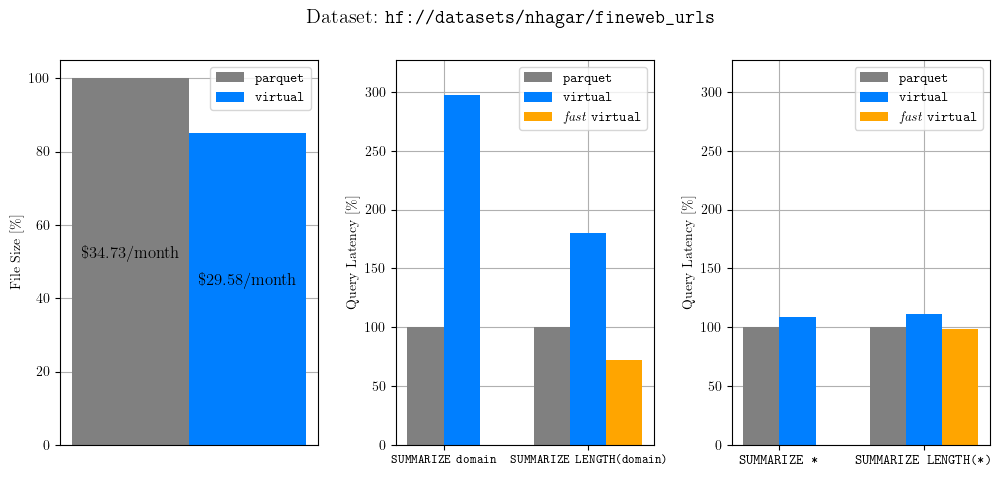

In [3]:
fineweb_url_plotter.plot_target_column("domain")

In [5]:
original_path = "./datasets_parquet/nhagar/fineweb_urls/nhagar_fineweb_urls.parquet"
compressed_path = "./datasets_compress/nhagar/fineweb_urls/nhagar_fineweb_urls-2.parquet"

fineweb_url_plotter = SummarizePlotter(original_path, compressed_path, "Fineweb_URLs")
fineweb_url_plotter.add_target_column(
    "url",
    "url_prefix || CASE WHEN is_outlier THEN LEFT(domain, LENGTH(domain) - 1) ELSE domain END || url_suffix",
    "LENGTH(url_prefix) + CASE WHEN is_outlier THEN LENGTH(domain) - 1 ELSE LENGTH(domain) END + LENGTH(url_suffix)"
)

Added target column: url


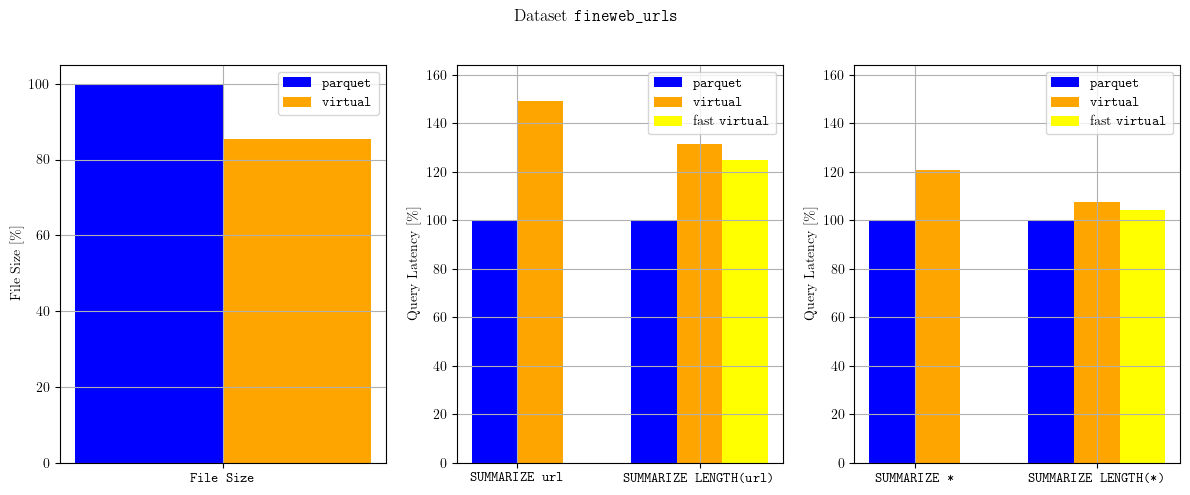

In [6]:
fineweb_url_plotter.plot_target_column("url")